# Diabetes Progression Prediction — Linear Regression Mini Project

**Goal:** Predict how far a diabetes will progress in a patient one year after their baseline measurements, using simple physiological data (age, BMI, blood pressure, blood serum readings, etc.)

**Dataset:** The `diabetes` dataset built into scikit-learn (`sklearn.datasets.load_diabetes`) — 442 patients, 10 baseline features, and a target that is a quantitative measure of disease progression.

**Why this project:** It's small enough to fully understand, but has enough features that we go beyond a single-line-fit toy example — a good middle ground between "trivial" and "overwhelming."

**What we'll do:**
1. Load and explore the data
2. Simple linear regression — predict progression from a single feature (BMI)
3. Multiple linear regression — predict progression from all 10 features
4. Compare the two models and see which features matter most


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Make plots look nicer
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42  # fixed seed so results are reproducible


## 1. Load the Data

`load_diabetes()` returns already-cleaned, already-scaled data (each feature has been mean-centered and scaled), so we don't need to worry about missing values or units here. We'll build a normal pandas DataFrame from it so it's easy to explore.

In [2]:
data = load_diabetes()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print("Shape:", df.shape)
df.head()


Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
# Column meanings (from the sklearn documentation):
# age, sex, bmi (body mass index), bp (average blood pressure),
# s1-s6: six blood serum measurements
# target: a quantitative measure of disease progression one year after baseline

df.describe()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [4]:
# Quick sanity check for missing values
df.isnull().sum()


age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

## 2. Explore the Data

Before modeling, let's look at:
- How the target variable is distributed
- Which features correlate most strongly with the target (these are our best predictor candidates)

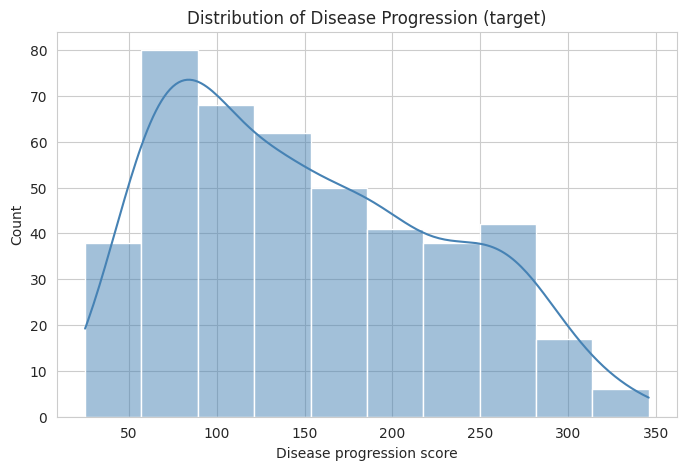

In [5]:
fig, ax = plt.subplots()
sns.histplot(df["target"], kde=True, ax=ax, color="steelblue")
ax.set_title("Distribution of Disease Progression (target)")
ax.set_xlabel("Disease progression score")
plt.show()


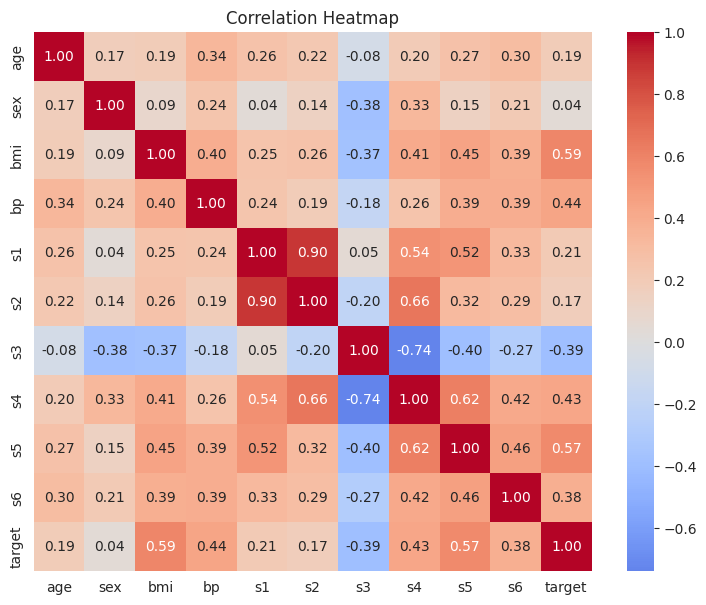

bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64

In [6]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.show()

# Which features correlate most with the target?
corr["target"].drop("target").sort_values(ascending=False)


**Observation:** `bmi` (body mass index) and `s5` tend to show the strongest correlation with disease progression, followed by `bp` (blood pressure). This matches medical intuition — higher BMI and blood pressure are known diabetes risk factors. We'll use `bmi` for our simple regression model.

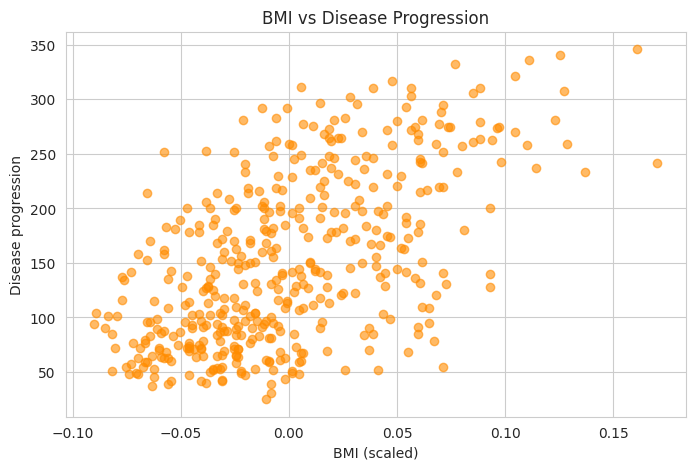

In [7]:
fig, ax = plt.subplots()
ax.scatter(df["bmi"], df["target"], alpha=0.6, color="darkorange")
ax.set_xlabel("BMI (scaled)")
ax.set_ylabel("Disease progression")
ax.set_title("BMI vs Disease Progression")
plt.show()


## 3. Simple Linear Regression (1 feature)

We'll start with the simplest possible model: predict `target` using only `bmi`.

Steps:
1. Split data into train/test sets
2. Fit a `LinearRegression` model
3. Evaluate with MSE, RMSE, MAE, and R²
4. Plot the fitted line against the actual data

In [8]:
X_simple = df[["bmi"]]   # double brackets -> keep it as a DataFrame, not a Series
y = df["target"]

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=RANDOM_STATE
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train)

y_pred_simple = simple_model.predict(X_test_s)

print(f"Intercept: {simple_model.intercept_:.2f}")
print(f"Coefficient (bmi): {simple_model.coef_[0]:.2f}")


Intercept: 152.00
Coefficient (bmi): 998.58


In [9]:
def evaluate(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAE  : {mae:.2f}")
    print(f"R^2  : {r2:.3f}")
    return {"model": model_name, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

simple_results = evaluate(y_test, y_pred_simple, "Simple Linear Regression (bmi only)")


--- Simple Linear Regression (bmi only) ---
MSE  : 4061.83
RMSE : 63.73
MAE  : 52.26
R^2  : 0.233


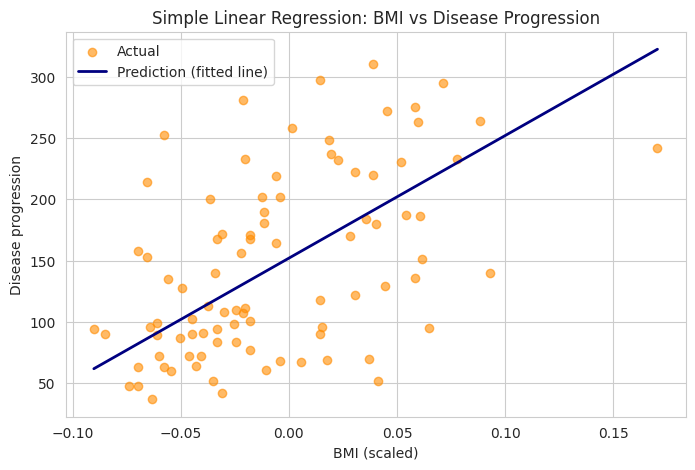

In [10]:
fig, ax = plt.subplots()
ax.scatter(X_test_s, y_test, alpha=0.6, label="Actual", color="darkorange")

# sort so the line draws cleanly left to right
order = X_test_s["bmi"].argsort()
ax.plot(X_test_s["bmi"].iloc[order], y_pred_simple[order], color="navy", linewidth=2, label="Prediction (fitted line)")

ax.set_xlabel("BMI (scaled)")
ax.set_ylabel("Disease progression")
ax.set_title("Simple Linear Regression: BMI vs Disease Progression")
ax.legend()
plt.show()


## 4. Multiple Linear Regression (all 10 features)

A single feature only tells part of the story. Now let's use **all 10 features** and see how much the predictions improve.

In [11]:
X_full = df.drop(columns=["target"])

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y, test_size=0.2, random_state=RANDOM_STATE
)

full_model = LinearRegression()
full_model.fit(X_train_f, y_train_f)

y_pred_full = full_model.predict(X_test_f)

full_results = evaluate(y_test_f, y_pred_full, "Multiple Linear Regression (all features)")


--- Multiple Linear Regression (all features) ---


MSE  : 2900.19
RMSE : 53.85
MAE  : 42.79
R^2  : 0.453


### Compare the two models

In [12]:
comparison = pd.DataFrame([simple_results, full_results]).set_index("model")
comparison


,MSE,RMSE,MAE,R2
model,,,,
Simple Linear Regression (bmi only),4061.825928,63.732456,52.259976,0.233350
Multiple Linear Regression (all features),2900.193628,53.853446,42.794095,0.452603


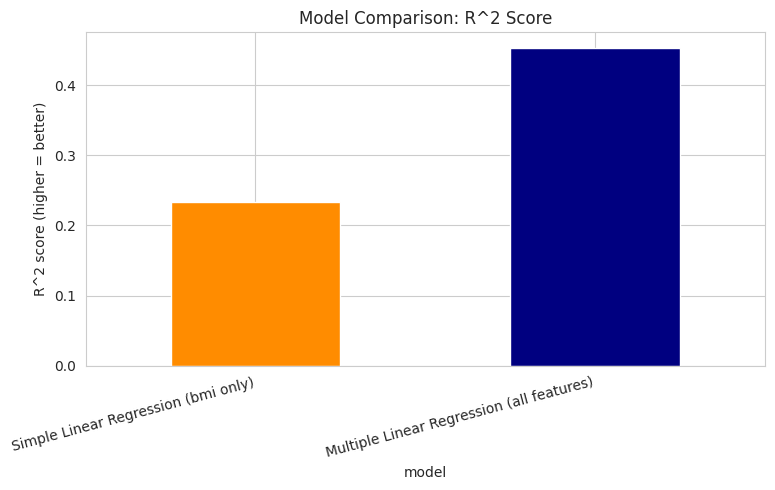

In [13]:
fig, ax = plt.subplots()
comparison["R2"].plot(kind="bar", color=["darkorange", "navy"], ax=ax)
ax.set_ylabel("R^2 score (higher = better)")
ax.set_title("Model Comparison: R^2 Score")
ax.set_xticklabels(comparison.index, rotation=15, ha="right")
plt.tight_layout()
plt.show()


## 5. Which Features Matter Most?

Since all features were already scaled by scikit-learn before we got the data, we can compare the regression coefficients directly to see which features push the prediction up or down the most.

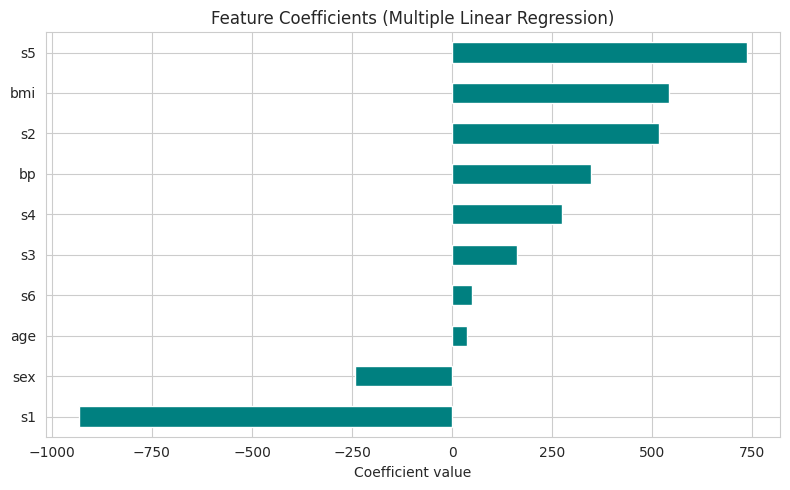

s5     736.198859
bmi    542.428759
s2     518.062277
bp     347.703844
s4     275.317902
s3     163.419983
s6      48.670657
age     37.904021
sex   -241.964362
s1    -931.488846
dtype: float64

In [14]:
coeffs = pd.Series(full_model.coef_, index=X_full.columns).sort_values()

fig, ax = plt.subplots()
coeffs.plot(kind="barh", color="teal", ax=ax)
ax.set_title("Feature Coefficients (Multiple Linear Regression)")
ax.set_xlabel("Coefficient value")
plt.tight_layout()
plt.show()

coeffs.sort_values(ascending=False)


## 6. Predicted vs Actual (Multiple Regression)

A quick way to visually judge model quality: if predictions were perfect, every point would sit exactly on the diagonal line.

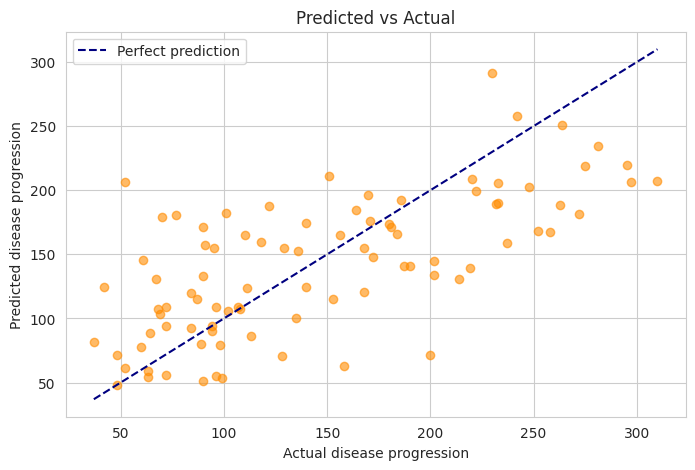

In [15]:
fig, ax = plt.subplots()
ax.scatter(y_test_f, y_pred_full, alpha=0.6, color="darkorange")

lims = [min(y_test_f.min(), y_pred_full.min()), max(y_test_f.max(), y_pred_full.max())]
ax.plot(lims, lims, color="navy", linestyle="--", label="Perfect prediction")

ax.set_xlabel("Actual disease progression")
ax.set_ylabel("Predicted disease progression")
ax.set_title("Predicted vs Actual")
ax.legend()
plt.show()


## 7. Conclusion

- Using **only BMI**, the simple linear regression model explains a moderate portion of the variance in disease progression.
- Adding **all 10 features** noticeably improves the R² score, confirming that blood pressure and serum measurements add real predictive value beyond BMI alone.
- `bmi`, `s5`, and `bp` turned out to be among the strongest predictors — consistent with known diabetes risk factors.

**Possible next steps (for extending this project):**
- Try regularized regression (Ridge / Lasso) to reduce overfitting
- Try non-linear models (Random Forest, Gradient Boosting) and compare
- Do k-fold cross-validation instead of a single train/test split for more reliable metrics
- Engineer interaction features (e.g., bmi × bp)
